In [1]:
%reload_ext autoreload
%autoreload 2
import slap2_py as spy
import wisco_slap as wis
import wisco_slap.defs as DEFS
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import matplotlib as mpl
import h5py
import glob
import polars as pl
from pathlib import Path
import tifffile
import seaborn as sns
import electro_py as epy
import cv2

import h5py
import numpy as np
from pathlib import Path
from typing import Any, Union
import h5py
import plotly.express as px

In [27]:
macq = wis.meta.get.acq_master()
for subject in macq.keys():
    for exp in macq[subject].keys():
        wis.meta.sync.update_sync_info(subject, exp)

All acquisitions already have sync info for menka exp_1. Use redo=True to update.
All acquisitions already have sync info for alkaid exp_2. Use redo=True to update.
All acquisitions already have sync info for alkaid exp_3. Use redo=True to update.
All acquisitions already have sync info for avior exp_1. Use redo=True to update.
All acquisitions already have sync info for avior exp_2. Use redo=True to update.
All acquisitions already have sync info for kaus exp_1. Use redo=True to update.
All acquisitions already have sync info for kaus exp_2. Use redo=True to update.
All acquisitions already have sync info for sargas exp_1. Use redo=True to update.
All acquisitions already have sync info for sargas exp_3. Use redo=True to update.
All acquisitions already have sync info for mirfak exp_1. Use redo=True to update.
All acquisitions already have sync info for mirfak exp_2. Use redo=True to update.
All acquisitions already have sync info for mirfak exp_3. Use redo=True to update.
All acquisi

IndexError: index 0 is out of bounds for axis 0 with size 0

In [30]:
si = wis.meta.get.sync_info()
wis.meta.sync.compute_ephys_offset('alnair', 'exp_7', 'loc_E', 'acq_1', si)

Loading sync block 1 from /run/user/1329238735/gvfs/smb-share:server=tononi-nas,share=slap_mi/slap_mi/data/alnair/exp_7/SYNC_00001.h5


IndexError: index 0 is out of bounds for axis 0 with size 0

In [30]:
subject = 'alnair'
exp = 'exp_7'
scope, ephys = wis.meta.sync.load_sync_block(subject, exp, 1)

Loading sync block 1 from /run/user/1329238735/gvfs/smb-share:server=tononi-nas,share=slap_mi/slap_mi/data/alnair/exp_7/SYNC_00001.h5


In [16]:
ephys

array([0.        , 0.00976562, 0.00946045, ..., 0.00396729, 0.00396729,
       0.00366211], shape=(27062016,), dtype=float32)

In [31]:
from wisco_slap.peri.ephys import get_ephys_sync_block_path
get_ephys_sync_block_path(subject, exp, 1)

'/run/user/1329238735/gvfs/smb-share:server=tononi-nas,share=slap_mi/slap_mi/data/alnair/exp_7/ephys/ephys-1'

In [32]:
import tdt
dat = tdt.read_block(get_ephys_sync_block_path(subject, exp, 1))

read from t=0s to t=8022.86s
Using 1017.2526 Hz as SEV sampling rate for Wav1
Using 610.3516 Hz as SEV sampling rate for EEG_
Using 1017.2526 Hz as SEV sampling rate for EEGr


In [43]:
def find_first_low_period_of_ephys_sync_signal(ephys, threshold=0.02, min_samples=(5000*1)):
    below = ephys < threshold
    count = 0
    for i in range(len(below)):
        if below[i]:
            count += 1
            if count >= min_samples:
                return i - min_samples + 1
        else:
            count = 0
    return None

In [44]:
find_first_low_period_of_ephys_sync_signal(ephys)

13350

In [45]:
dat.streams.EEGr.data.shape[1]/1017.2526

8022.739877981142

In [40]:
px.line(ephys[:100000])

In [38]:
start = 36662 
end = len(ephys) - 15358

In [39]:
(end - start)/5000

8022.876

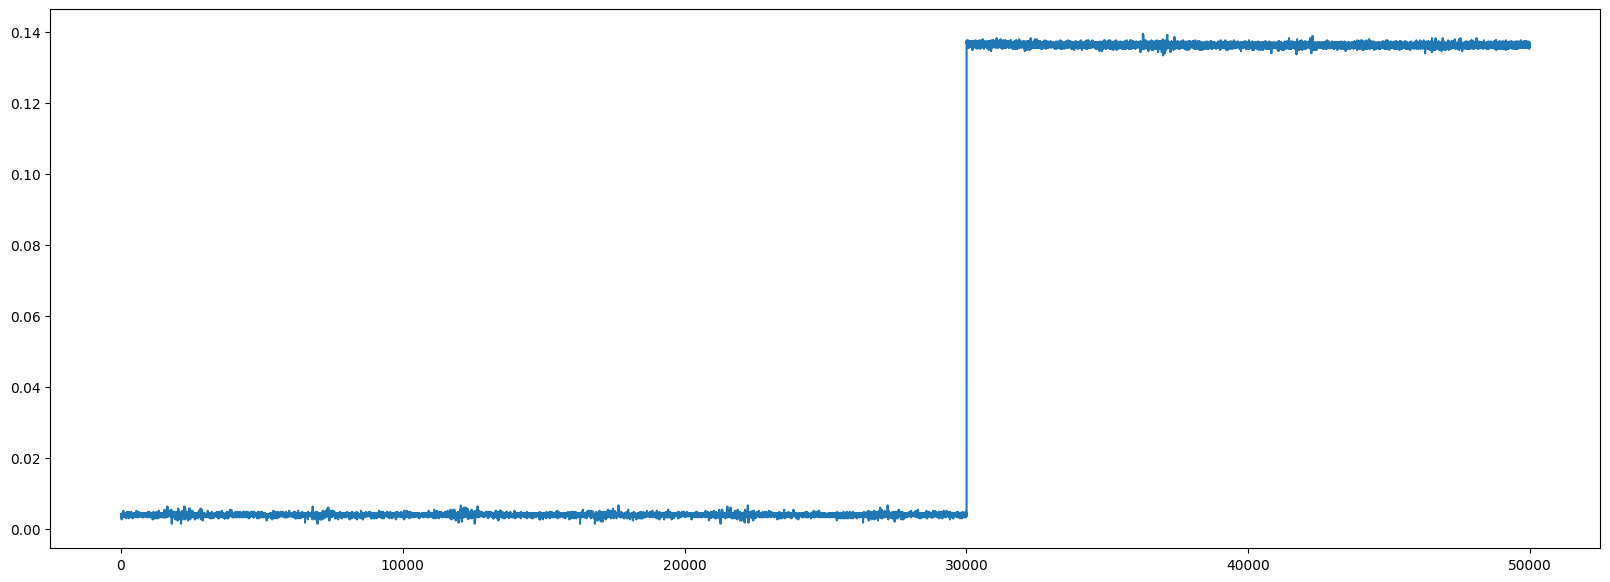

In [6]:
fs = 5000
f, ax = plt.subplots(1, 1, figsize=(20, 7))
ax.plot(ephys[:50000])

In [2]:
subject = 'alnair'
exp = 'exp_7'
scope, ephys = wis.meta.sync.load_sync_block(subject, exp, 1)

Loading sync block 1 from /run/user/1329238735/gvfs/smb-share:server=tononi-nas,share=slap_mi/slap_mi/data/alnair/exp_7/SYNC_00001.h5


In [5]:
from wisco_slap.peri.ephys import get_ephys_sync_block_path
get_ephys_sync_block_path(subject, exp, 1)

'/run/user/1329238735/gvfs/smb-share:server=tononi-nas,share=slap_mi/slap_mi/data/alnair/exp_7/ephys/ephys-1'

In [6]:
import tdt
dat = tdt.read_block(get_ephys_sync_block_path(subject, exp, 1))

read from t=0s to t=8022.86s
Using 1017.2526 Hz as SEV sampling rate for Wav1
Using 610.3516 Hz as SEV sampling rate for EEG_
Using 1017.2526 Hz as SEV sampling rate for EEGr


In [34]:
dat.streams.EEGr.data.shape[1]/1017.2526

8022.739877981142

In [19]:
len(ephys) - 15358

40151042

In [26]:
40151042 - 36661

40114381

In [29]:
40114381/5000

8022.8762

In [18]:
100000 - 84642

15358

In [15]:
px.line(ephys[0:100000])

In [17]:
px.line(ephys[-100000:])

In [37]:
subject = 'alnilam'
exp = 'exp_2'
scope, ephys = wis.meta.sync.load_sync_block(subject, exp, 1)

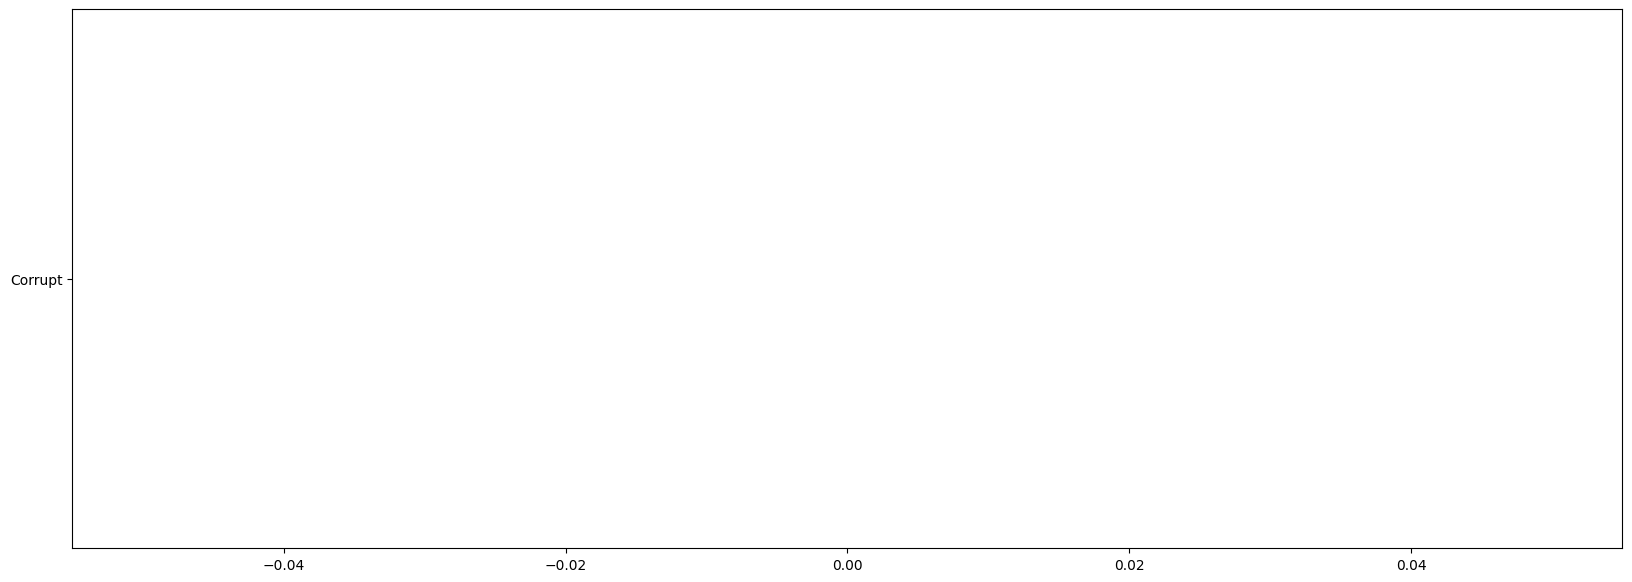

In [36]:
fs = 5000
f, ax = plt.subplots(1, 1, figsize=(20, 7))
ax.plot(ephys[:])

In [56]:
subject = 'alnilam'
exp = 'exp_3'
scope, ephys = wis.meta.sync.load_sync_block(subject, exp, 1)

Loading sync block 1 from /run/user/1329238735/gvfs/smb-share:server=tononi-nas,share=slap_mi/slap_mi/data/alnilam/exp_3/SYNC_00001.h5


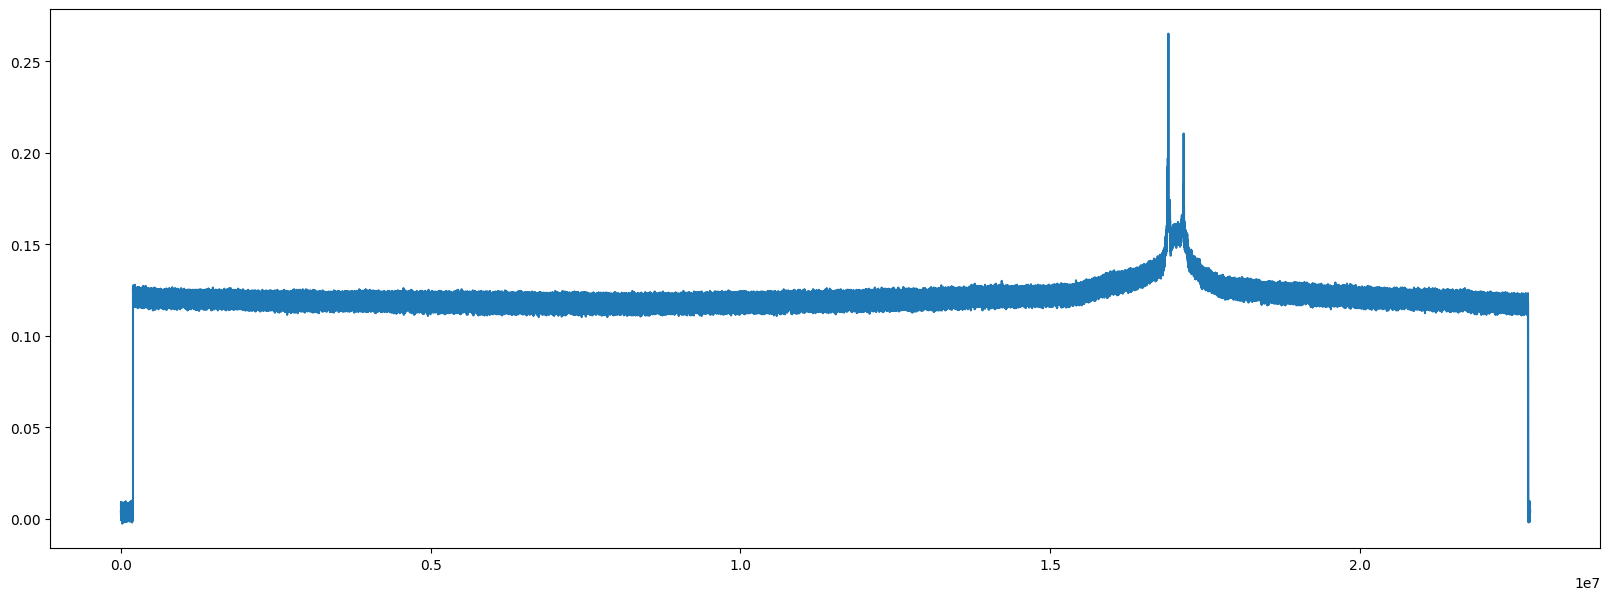

In [57]:
fs = 5000
f, ax = plt.subplots(1, 1, figsize=(20, 7))
ax.plot(ephys[:])

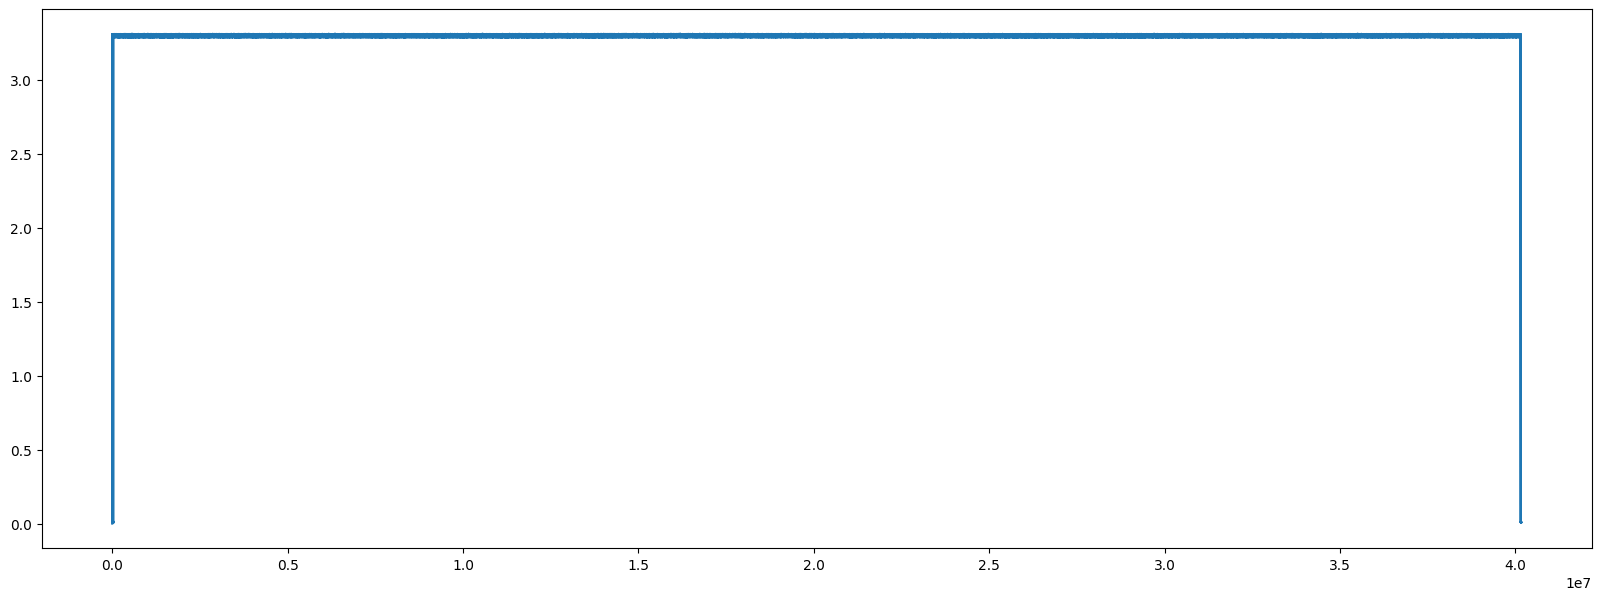

In [ ]:
fs = 5000
f, ax = plt.subplots(1, 1, figsize=(20, 7))
ax.plot(ephys[:])

# Complete Analysis Pipeline (post ophys-slap2-analysis)

In [4]:
subject = 'sargas'
exp = 'exp_3'
loc = 'loc_B'
acq = 'acq_1'

## 1. Update Experiment info

In [ ]:
# wis.pns.exp_info.update_exp_info_spreadsheet() # deprecate all reliance on this spreadsheet
wis.meta.sync.update_sync_info(subject, exp, redo=False) # update the sync info
wis.pns.exp_info._update_dmd_info(subject, exp, loc, acq) # update the dmd info
wis.pns.annotation_materials.full_annotation_pipeline(subject, exp, loc, acq) # run the full annotation pipeline

#Get the sync block for subsequent steps
sb = wis.meta.sync.get_acq_sync_block(subject, exp, loc, acq)

# Generate the video frame stack for whisker annotation
wis.pns.videos._save_video_frame_stack(subject, exp, sb, n_frames=20, redo=False)

## 2. Perform Annotations

1. Label averaged images on the canvas, notably tracing each DMD to its soma, and associating a dend-ID. Also estimate DMD depth here and mark on the image. Use the reference anatomy stacks which should be collected after the experiment.
2. Update dmd_info.yaml with the DMD depths labelled in #1.
3. label the soma_roi locations on their respective tiff images in napari.
4. use the syanpse labeller to classify all synapses with their soma, dend-ID, type, etc.
5. label the whisker pixels (open napari window, then open whisker stack and label) Note: can simply launch ROI viewer, close the ROI stacks, and open the video stack.

## 3. Save Extracted Dataframes

In [ ]:
wis.pns.traces.gen_and_save_all_activity_dfs(subject, exp, loc, acq, overwrite=False)
wis.pns.videos._run_pupil_inference(subject, exp, redo=False)
wis.pns.videos._save_full_exp_eye_dfs(subject, exp, redo=False)
wis.pns.videos._save_whisking_frame_differences(subject, exp, sb, redo=False)

## 4. Complete the Sleepscoring Pipeline

In [ ]:
# generate all scoring data
wis.pns.sleepscore.full_scoring_data_pipeline(subject, exp, loc, acq, overwrite=False)

Now, pop open the sleepscoring data and update sb_scoring_times.yaml to specify the periods with good/usable data that can be fed to the model.

In [ ]:
# autoscore the experiment
wis.pns.score_mi._autoscore_mi(subject, exp, sb, overwrite=False)

In [6]:
# Generate the full synaptic movies
wis.pns.synmovies.make_full_syn_movies(subject, exp, loc, acq, t1=None, t2=None)

1
2


/Users/driessen2@ad.wisc.edu/kdriessen/FINAL-slap2-dev/wisco-slap/src/wisco_slap/scope/somas.py:47: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(W + C, w * y)
/Users/driessen2@ad.wisc.edu/kdriessen/FINAL-slap2-dev/wisco-slap/src/wisco_slap/scope/somas.py:246: PeakPropertyWarning: some peaks have a prominence of 0
  w_samples, _, _, _ = peak_widths(z_aligned_uni, refined_pk_uni, rel_height=0.5)
/Users/driessen2@ad.wisc.edu/kdriessen/FINAL-slap2-dev/wisco-slap/src/wisco_slap/scope/somas.py:246: PeakPropertyWarning: some peaks have a width of 0
  w_samples, _, _, _ = peak_widths(z_aligned_uni, refined_pk_uni, rel_height=0.5)


(57661,)
(57661,)
(2, 950, 578)
(2, 786, 342)
/Volumes/slap_mi/slap_mi/analysis_materials/annotation_materials/sargas/exp_3/loc_B/acq_1/roi_locations/roi_locs_dmd1_mask.tif does not exist!
GENERATING MOVIE WITHOUT ROIS FOR DMD 1


/Users/driessen2@ad.wisc.edu/kdriessen/FINAL-slap2-dev/wisco-slap/src/wisco_slap/pipes/synmovies.py:134: RuntimeWarning: invalid value encountered in cast
  return (x * 255.0 + 0.5).astype(np.uint8)


[make_activity_movie] encoded 100/57660 frames
[make_activity_movie] encoded 200/57660 frames
[make_activity_movie] encoded 300/57660 frames
[make_activity_movie] encoded 400/57660 frames
[make_activity_movie] encoded 500/57660 frames
[make_activity_movie] encoded 600/57660 frames
[make_activity_movie] encoded 700/57660 frames
[make_activity_movie] encoded 800/57660 frames
[make_activity_movie] encoded 900/57660 frames
[make_activity_movie] encoded 1000/57660 frames
[make_activity_movie] encoded 1100/57660 frames
[make_activity_movie] encoded 1200/57660 frames
[make_activity_movie] encoded 1300/57660 frames
[make_activity_movie] encoded 1400/57660 frames
[make_activity_movie] encoded 1500/57660 frames
[make_activity_movie] encoded 1600/57660 frames
[make_activity_movie] encoded 1700/57660 frames
[make_activity_movie] encoded 1800/57660 frames
[make_activity_movie] encoded 1900/57660 frames
[make_activity_movie] encoded 2000/57660 frames
[make_activity_movie] encoded 2100/57660 frames
[